In [1]:
pip install tensorflow keras

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 2.4/332.0 MB 18.7 MB/s eta 0:00:18
   - -------------------------------------- 10.2/332.0 MB 31.8 MB/s eta 0:00:11
   - -------------------------------------- 16.5/332.0 MB 31.1 MB/s eta 0:00:11
   --- ------------------------------------ 26.0/332.0 MB 33.8 MB/s eta 0:00:10
   ---- ----------------------------------- 34.1/332.0 MB 34.9 MB/s eta 0:00:09
   ---- ----------------------------------- 41.4/332.0 MB 35.0 MB/s eta 0:00:09
   ------ --------------------------------- 50.9/332.0 MB 36.6 MB/s eta 0:00:08
   ------- -------------------------------- 58.2/332.0 MB 36.3 MB/s eta 0:00:08
   ------- -------------------------------- 66.1/332.0 MB 36.2 MB/s eta 0:00:08
   -------- ------------------------------- 73.4/332.0 MB 36.0 MB/s eta 0:00:08
   --------- ------------------------------ 78.9/332.0 MB 36.3 MB/s eta 0:00:07
   ---------- ----------------------------- 86.2/3

In [1]:
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.datasets import cifar10

In [16]:
class_names = [ "bee", "airplane", "bee", "automobile", "bee", "bird", "bee", "cat", "bee", "deer", "bee", "dog", "bee", "horse", "bee", "ship", "bee", "truck", "bee" ]
# Loading Datasets
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train[0:10000,:,:,:];
y_train = y_train[0:10000];

In [17]:
x_train = x_train / 255.0
print(x_train.shape)

x_test = x_test / 255.0
print(x_test.shape)

(10000, 32, 32, 3)
(10000, 32, 32, 3)


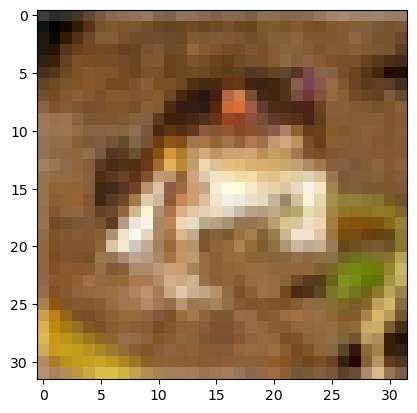

In [18]:
plt.imshow(x_train[0])

In [19]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)))
model.add(Conv2D(32, 3, activation="relu", padding="same"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(units=128, activation="relu"))
model.add(Dense(units=10, activation="softmax"))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="Adam", metrics=[ "sparse_categorical_accuracy" ])

In [22]:
model.fit(x_train, y_train, epochs=10)
model.save("bee_model.h5")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.7520 - sparse_categorical_accuracy: 0.3612
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3626 - sparse_categorical_accuracy: 0.5117
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.1809 - sparse_categorical_accuracy: 0.5821
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.0821 - sparse_categorical_accuracy: 0.6104
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.9804 - sparse_categorical_accuracy: 0.6532
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.8608 - sparse_categorical_accuracy: 0.6860
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7768 - sparse_categorical_accuracy: 0.7263
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.6835 - sparse_categorical_accuracy: 0.7559
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.5939 - sparse_categorical_accuracy: 0.7872
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10

In [23]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy: {}".format(test_accuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2784 - sparse_categorical_accuracy: 0.5981
Test Accuracy: 0.5981000065803528


In [24]:
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.models import load_model

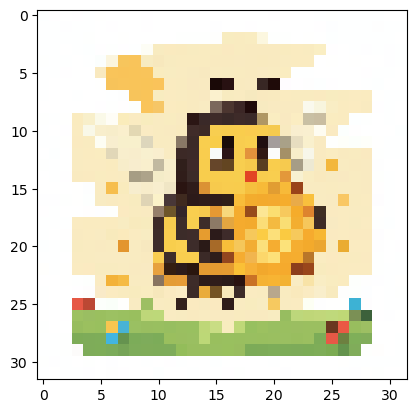

In [25]:
img = load_img("./assets/Gemini_Generated_Image_ojb7tojb7tojb7to.png", target_size=(32, 32))
img = img_to_array(img)
img = img.reshape(1, 32, 32, 3)
img = img.astype("float32")
img = img / 255.0

plt.imshow(img[0])

In [26]:
model = load_model("bee_model.h5")
result = model.predict(img)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[3.14766257e-05, 2.78943553e-05, 3.71477404e-03, 4.92615663e-02,
        1.18611344e-04, 4.16318915e-04, 9.46357667e-01, 5.03542014e-06,
        1.59472893e-05, 5.06885990e-05]], dtype=float32)

In [27]:
import numpy as np

In [28]:
index_result = np.argmax(result)
index_result

np.int64(6)

In [29]:
class_names[index_result]

'bee'